In [33]:
# Cell 1: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.base import clone

In [34]:
# Cell 2: Load data

df = pd.read_csv("master_zillow_with_taxes.csv")
print("Shape:", df.shape)
df.head()

Shape: (2159, 29)


,Unnamed: 0,zpid,address,price,beds,baths,area_sqft,latitude,longitude,status,...,state_code,zipcode,state_name,state_avg_housing_value,state_avg_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets
0,0,17264897,"979 Kevin Ave, Redlands, CA 92373",447000,3,2.0,1300.0,34.040520,-117.186195,House for sale,...,CA,92373,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0
1,1,20021372,"13114 Addison St, Sherman Oaks, CA 91423",2795000,4,5.0,2900.0,34.160885,-118.418770,House for sale,...,CA,91423,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0
2,2,20009320,"6032 Goodland Ave, North Hollywood, CA 91606",1718000,4,3.0,3025.0,34.180450,-118.411280,House for sale,...,CA,91606,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0
3,3,460204882,"3325 Tonopah St, Oceanside, CA 92054",899999,3,3.0,1682.0,33.214260,-117.341500,Coming soon,...,CA,92054,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0
4,4,20769150,"963 Pine Grove Ave, Los Angeles, CA 90042",995000,2,2.0,1271.0,34.132890,-118.186220,House for sale,...,CA,90042,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0


In [35]:
# Cell 3: Quick check of target and zestimate

print(df[["price", "zestimate"]].describe())
print("\nMissing zestimate values:", df["zestimate"].isna().sum())
print("Total rows:", len(df))

              price     zestimate
count  2.159000e+03  1.085000e+03
mean   1.350735e+06  7.107092e+05
std    8.643195e+06  1.542531e+06
min    1.000000e+00  2.920000e+04
25%    3.350000e+05  3.470000e+05
50%    4.950000e+05  4.908000e+05
75%    7.599000e+05  7.423000e+05
max    3.000000e+08  4.079420e+07

Missing zestimate values: 1074
Total rows: 2159


In [36]:
# Cell 4: Prepare X and y

target = "price"

drop_cols = [
    "price",
    "Unnamed: 0",
    "zpid",
    "address",
    "detail_url",
    "street_add"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
y = df[target].copy()

bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Target:", target)
print("Number of features:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Target: price
Number of features: 23
Numeric features: ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'days_on_zillow', 'zestimate', 'has_open_house', 'is_featured', 'state_avg_housing_value', 'state_avg_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates', 'single_filer_brackets', 'married_filing_jointly_rates', 'married_filing_jointly_brackets']
Categorical features: ['status', 'home_type', 'city', 'state_zipcode', 'state_code', 'zipcode', 'state_name']


In [37]:
# Cell 5: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1727, 23)
X_test shape: (432, 23)


In [38]:
# Cell 6: Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)

In [39]:
# Cell 7: Define bagging and boosting models
# We use log(price) through TransformedTargetRegressor to handle extreme outliers better

base_tree_for_bagging = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)

base_tree_for_adaboost = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

bagging_model = BaggingRegressor(
    estimator=base_tree_for_bagging,
    n_estimators=120,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

adaboost_model = AdaBoostRegressor(
    estimator=base_tree_for_adaboost,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

models = {
    "Bagging Regressor": bagging_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boosting_model
}


In [40]:
# Cell 8: Train and evaluate models

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    log_model = TransformedTargetRegressor(
        regressor=clone(model),
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", log_model)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = np.maximum(pipe.predict(X_train), 0)
    y_test_pred = np.maximum(pipe.predict(X_test), 0)

    results.append({
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred)
    })

    trained_models[name] = pipe
    predictions[name] = y_test_pred

results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)
results_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,Bagging Regressor,5.808620e+06,2.578128e+06,467076.954474,480201.444897,0.624472,0.523187
1,AdaBoost,5.754874e+06,2.778733e+06,564922.582835,592909.110349,0.631389,0.446098
2,Gradient Boosting,2.801162e+06,2.921995e+06,341899.213598,560993.606539,0.912668,0.387511


In [41]:
# Cell 9: Print results

for _, row in results_df.iterrows():
    print(f"Model: {row['Model']}")
    print(f"  Train RMSE: {row['Train RMSE']:.2f}")
    print(f"  Test RMSE:  {row['Test RMSE']:.2f}")
    print(f"  Train MAE:  {row['Train MAE']:.2f}")
    print(f"  Test MAE:   {row['Test MAE']:.2f}")
    print(f"  Train R2:   {row['Train R2']:.4f}")
    print(f"  Test R2:    {row['Test R2']:.4f}")
    print("-" * 50)

Model: Bagging Regressor
  Train RMSE: 5808620.30
  Test RMSE:  2578128.30
  Train MAE:  467076.95
  Test MAE:   480201.44
  Train R2:   0.6245
  Test R2:    0.5232
--------------------------------------------------
Model: AdaBoost
  Train RMSE: 5754874.35
  Test RMSE:  2778732.90
  Train MAE:  564922.58
  Test MAE:   592909.11
  Train R2:   0.6314
  Test R2:    0.4461
--------------------------------------------------
Model: Gradient Boosting
  Train RMSE: 2801161.94
  Test RMSE:  2921994.68
  Train MAE:  341899.21
  Test MAE:   560993.61
  Train R2:   0.9127
  Test R2:    0.3875
--------------------------------------------------


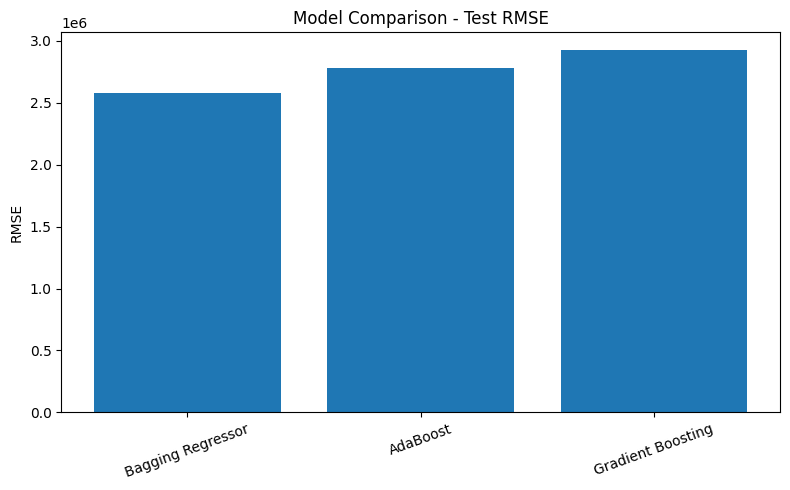

In [42]:
# Cell 10: Plot comparison of Test RMSE

plot_df = results_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["Test RMSE"])
plt.title("Model Comparison - Test RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

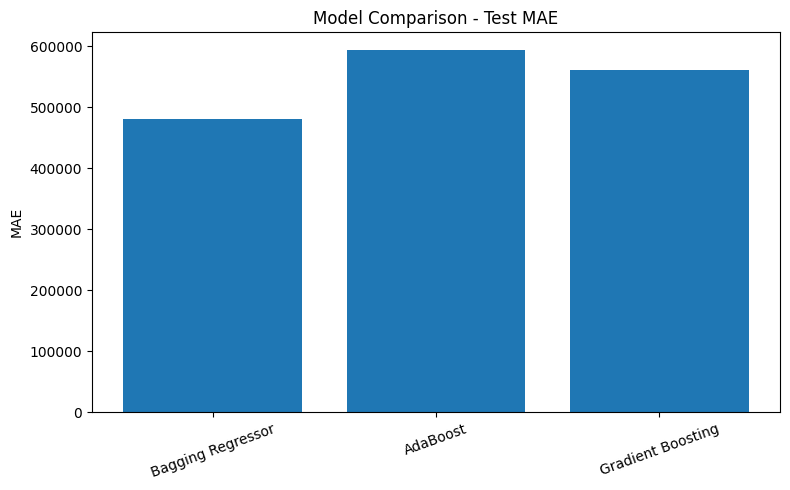

In [43]:
# Cell 11: Plot comparison of Test MAE

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["Test MAE"])
plt.title("Model Comparison - Test MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

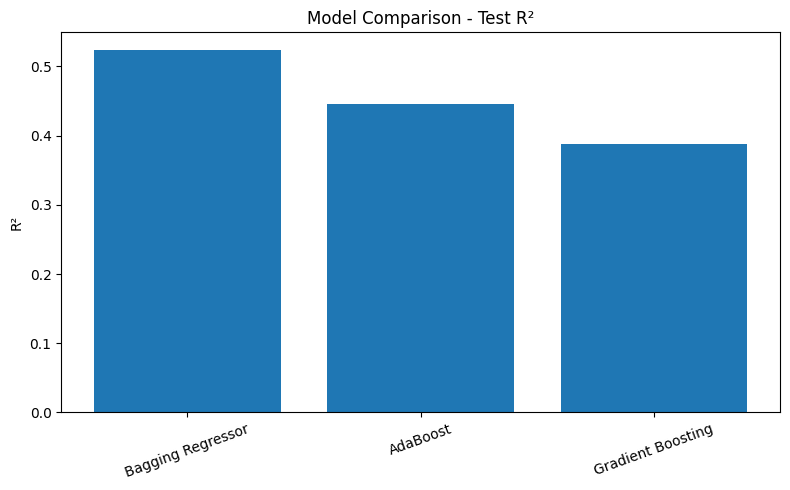

In [44]:
# Cell 12: Plot comparison of Test R2

plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["Test R2"])
plt.title("Model Comparison - Test R²")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

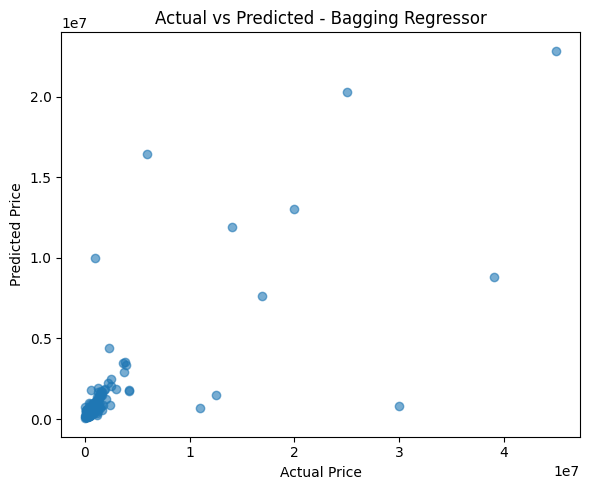

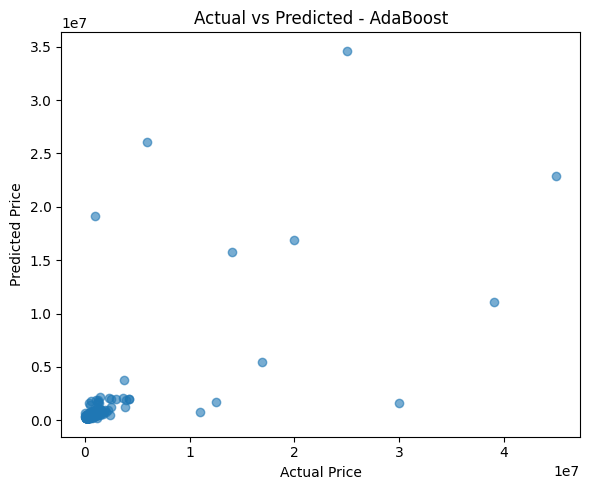

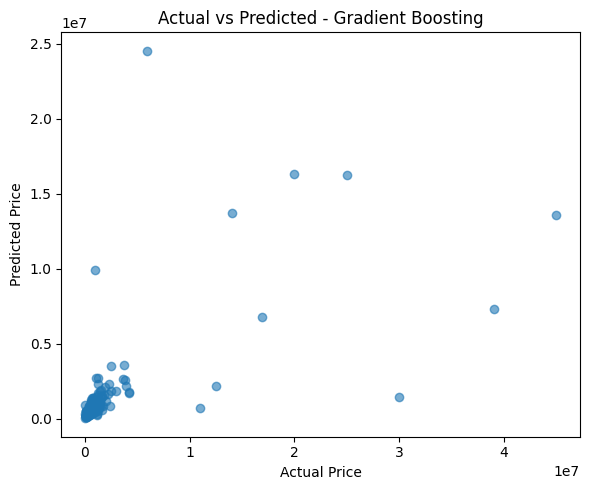

In [45]:
# Cell 13: Actual vs Predicted plot for each model

for name in results_df["Model"]:
    y_pred = predictions[name]

    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Actual vs Predicted - {name}")
    plt.tight_layout()
    plt.show()

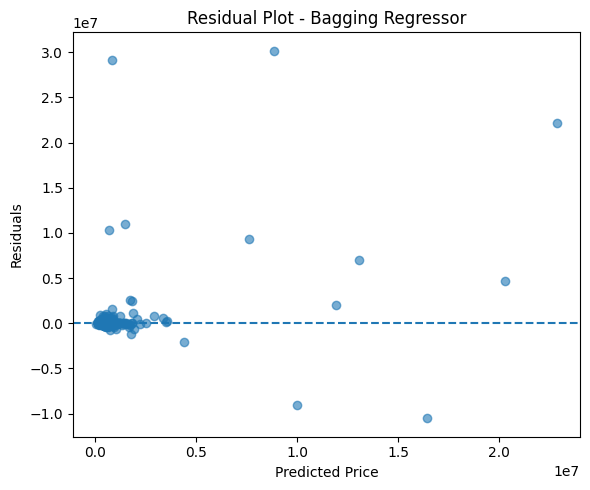

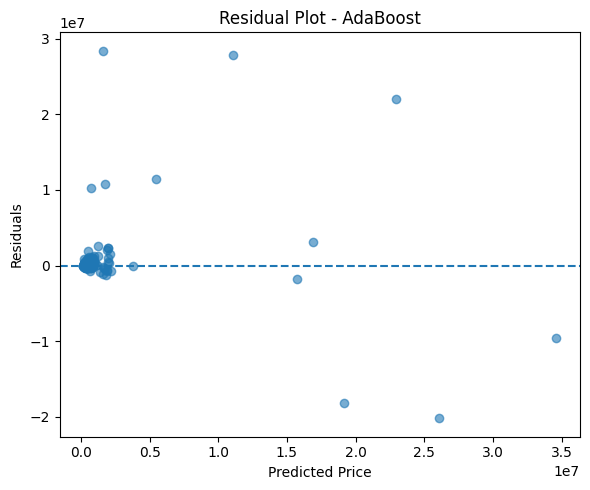

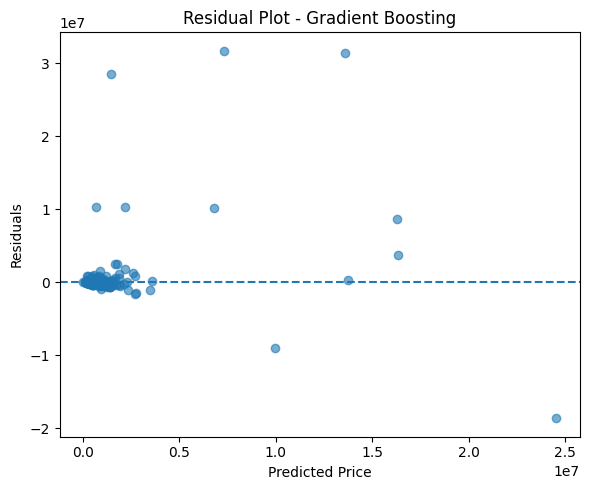

In [46]:
# Cell 14: Residual plot for each model

for name in results_df["Model"]:
    y_pred = predictions[name]
    residuals = y_test.values - y_pred

    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {name}")
    plt.tight_layout()
    plt.show()

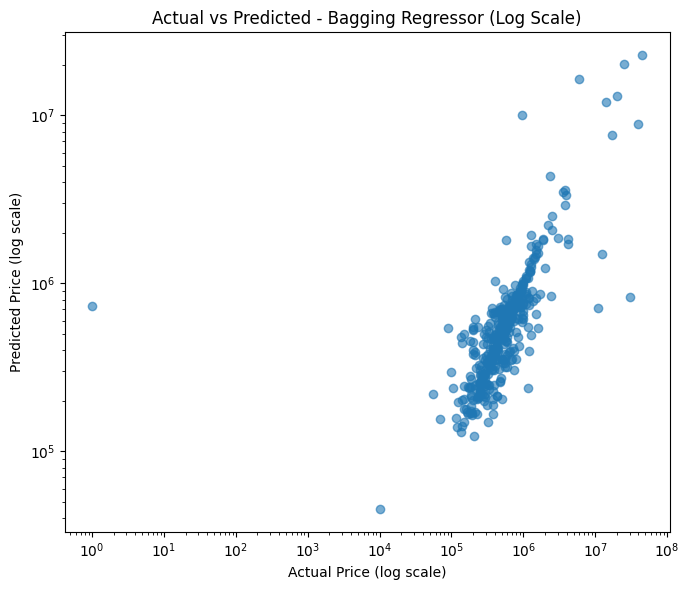

In [47]:
# Cell: Better Actual vs Predicted plot using log scale

best_model_name = results_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Price (log scale)")
plt.ylabel("Predicted Price (log scale)")
plt.title(f"Actual vs Predicted - {best_model_name} (Log Scale)")
plt.tight_layout()
plt.show()

In [48]:
# Cell 15: Best model and sample predictions in normal dollar format

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = np.maximum(best_model.predict(X_test), 0)

print("Best model:", best_model_name)

comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

comparison_df_display = comparison_df.copy()
comparison_df_display["Actual Price"] = comparison_df_display["Actual Price"].map(lambda x: f"${x:,.0f}")
comparison_df_display["Predicted Price"] = comparison_df_display["Predicted Price"].map(lambda x: f"${x:,.0f}")

comparison_df_display.head(15)

Best model: Bagging Regressor


,Actual Price,Predicted Price
0,"$134,500","$130,130"
1,"$549,000","$599,854"
2,"$249,900","$254,203"
3,"$1,185,000","$1,342,035"
4,"$475,000","$256,807"
5,"$296,000","$292,591"
6,"$365,000","$348,363"
7,"$10,000","$45,092"
8,"$45,000,000","$22,848,998"
9,"$249,900","$222,041"


In [53]:
# Cell: Custom accuracy = predictions within 15% of actual price

for name in results_df["Model"]:
    y_pred = predictions[name]
    within_15 = np.mean(np.abs(y_test - y_pred) / y_test <= 0.15) * 100
    print(f"{name} Accuracy within 15%: {within_15:.2f}%")

Bagging Regressor Accuracy within 15%: 49.77%
AdaBoost Accuracy within 15%: 30.32%
Gradient Boosting Accuracy within 15%: 37.27%
